# 06 — Person-Days Analysis: TX90p (calendar-day) thresholds

Mirrors `04_person_days_analysis` but replaces the **flat per-pixel percentile baseline**
with **ETCCDI-style calendar-day percentile thresholds** precomputed in `02_compute_baselines`
and used in `05_heat_days_tx90p`.

The heat-day definition here uses a centred 5-day moving-window threshold: a day
is flagged when observed Tmax exceeds the P90 (or P95/P99) value for *that specific
day of the year*, removing the annual cycle before defining extremes.  Person-days
are then the pixel-wise product of heat-day count and population, summed to
neighbourhood level.

**Prerequisites:**
- `01_data_acquisition` (temperature + population download)
- `02_compute_baselines` (TX90p calendar-day thresholds + population-to-1km resampling)

## Methodological difference from notebook 04

Notebook 04 computes person-days using a **flat percentile baseline**: each pixel has
a single percentile value pooled across all days of the year (e.g. the 90th percentile
of the full 2003–2020 Tmax record).  A warm winter day and a warm summer day are both
judged against the same annual threshold.

This notebook uses **calendar-day percentile thresholds**: for each of the 365 days of
the year, the percentile is estimated from values within a centred **5-day moving window**
(±2 days around that calendar day, pooled across all years in the reference period).
Each day is judged against its own seasonal norm — the P90 result is the ETCCDI TX90p index.

## Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.patches as mpatches
import xarray as xr
import geopandas as gpd

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES,
    load_city,
    load_tx90p_threshold,
    load_neighbourhood_boundaries,
    compute_absolute_heat_days,
    compute_person_days_map,
    aggregate_person_days_to_neighbourhoods,
    plot_person_days_quadrant,
)

In [2]:
# Analysis parameters — edit here, not inside functions
DATA_DIR          = 'data'
YEAR              = 2020          # representative year for spatial maps
PERCENTILE        = 90            # TX90p percentile for maps and quadrant
ABS_THRESHOLD     = 30.0          # absolute Tmax threshold in degrees C
TX90P_PERCENTILES = [90, 95, 99]  # calendar-day percentile levels to compare
CITY_KEYS         = ['salvador', 'teresina', 'caceres']
ALL_YEARS         = list(range(2003, 2021))

COLOURS = {
    f'Abs \u2265{ABS_THRESHOLD:.0f} \u00b0C': '#333333',
    'P90': '#e07b39',
    'P95': '#c0392b',
    'P99': '#7b0e0e',
}

# Load Tmax DataArrays — must set units attr for xclim compatibility
cities = {}
for c in CITY_KEYS:
    da = load_city(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities[c] = da

# Load calendar-day TX90p thresholds (precomputed in 02_compute_baselines)
thresholds = {c: load_tx90p_threshold(c, DATA_DIR) for c in CITY_KEYS}

# Load neighbourhood boundaries
gdfs = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
salvador TX90p threshold: shape {'percentile': 3, 'lat': 55, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 26.0–88.4 °C
teresina TX90p threshold: shape {'percentile': 3, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 32.7–65.9 °C
caceres TX90p threshold: shape {'percentile': 3, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95, 99]  range 30.9–52.7 °C
Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


In [3]:
def load_pop_grid(city: str, year: int) -> xr.DataArray:
    """Load cached 1km population grid for a city and year."""
    path = f'{DATA_DIR}/{city}_pop_1km_{year}.nc'
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{path} not found — run 02_compute_baselines population section first.'
        )
    return xr.open_dataset(path)['population']


def count_doy_exceedances(da: xr.DataArray, thresh_doy: xr.DataArray) -> xr.DataArray:
    """Annual count of days where da > calendar-day threshold thresh_doy."""
    thresh_aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > thresh_aligned).resample(time='YS').sum(dim='time')


# Pre-compute TX90p annual heat-day counts for all cities and percentile levels
# tx_annual[city][percentile] -> DataArray (year, lat, lon)
tx_annual = {c: {} for c in CITY_KEYS}
for c in CITY_KEYS:
    for p in TX90P_PERCENTILES:
        tx_annual[c][p] = count_doy_exceedances(
            cities[c], thresholds[c].sel(percentile=p)
        )
        mean_days = float(tx_annual[c][p].mean(dim=['lat', 'lon']).mean())
        print(f'{c}  P{p}: city-wide mean {mean_days:.1f} heat days/year')

salvador  P90: city-wide mean 11.1 heat days/year
salvador  P95: city-wide mean 4.9 heat days/year
salvador  P99: city-wide mean 1.1 heat days/year
teresina  P90: city-wide mean 33.7 heat days/year
teresina  P95: city-wide mean 15.0 heat days/year
teresina  P99: city-wide mean 3.8 heat days/year
caceres  P90: city-wide mean 34.2 heat days/year
caceres  P95: city-wide mean 15.5 heat days/year
caceres  P99: city-wide mean 3.6 heat days/year


## Spatial maps

Side-by-side choropleth maps for each city showing neighbourhood-level **total person-days**
of heat exposure under two threshold framings:

- **Absolute:** days where Tmax \u2265 30 \u00b0C \u00d7 population per pixel, summed to neighbourhood
- **TX90p calendar-day:** days where Tmax exceeds the seasonally calibrated 90th-percentile
  threshold for that day of year \u00d7 population per pixel, summed to neighbourhood

Colour is rank-based so within-city variation is always visible.

In [4]:
def plot_tx90p_person_days_maps(
    city_key: str,
    year: int,
    percentile: int = 90,
) -> tuple:
    """Side-by-side choropleth: absolute vs TX90p person-days per neighbourhood."""
    da    = cities[city_key]
    gdf   = gdfs[city_key]
    label = CITIES[city_key]['label']

    pop_grid  = load_pop_grid(city_key, year)

    abs_map  = compute_absolute_heat_days(da, year, ABS_THRESHOLD)
    tx_yr    = (
        tx_annual[city_key][percentile]
        .isel(time=(tx_annual[city_key][percentile].time.dt.year == year))
        .squeeze('time')
    )

    pd_abs = compute_person_days_map(abs_map, pop_grid)
    pd_tx  = compute_person_days_map(tx_yr,   pop_grid)

    abs_nbhd = aggregate_person_days_to_neighbourhoods(pd_abs, gdf)
    tx_nbhd  = aggregate_person_days_to_neighbourhoods(pd_tx,  gdf)

    cmap_obj = mcm.get_cmap('YlOrRd')
    mean_thr = float(thresholds[city_key].sel(percentile=percentile).mean())
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    panels = [
        (abs_nbhd, axes[0], f'Absolute: Tmax \u2265 {ABS_THRESHOLD:.0f} \u00b0C  ({year})'),
        (tx_nbhd,  axes[1], f'P{percentile} calendar-day TX90p  (ann-mean {mean_thr:.1f} \u00b0C)  ({year})'),
    ]
    for nbhd_gdf, ax, title in panels:
        series  = nbhd_gdf['total_person_days']
        working = nbhd_gdf.copy()
        working['_rank'] = series.rank(pct=True, method='first', na_option='keep')
        working.plot(
            column='_rank', ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            edgecolor='black', linewidth=0.4, legend=False,
            missing_kwds={'color': 'lightgrey', 'edgecolor': 'black', 'linewidth': 0.4},
        )
        valid_idx     = working['_rank'].dropna().index
        ranked_series = series.loc[valid_idx].sort_values()
        n_valid       = len(ranked_series)
        handles = []
        for i in range(5):
            lo_i = int(i * n_valid / 5)
            hi_i = int((i + 1) * n_valid / 5)
            band = ranked_series.iloc[lo_i:hi_i]
            handles.append(mpatches.Patch(
                facecolor=cmap_obj((i * 2 + 1) / 10),
                label=f'{band.min():,.0f}\u2013{band.max():,.0f} pd',
            ))
        n_nan = series.isna().sum()
        if n_nan:
            handles.append(mpatches.Patch(facecolor='lightgrey', label=f'No data ({n_nan})'))
        ax.legend(handles=handles, title='Person-days\n(quintile rank)',
                  fontsize=7, title_fontsize=7, loc='lower left')
        for _, row in nbhd_gdf.iterrows():
            cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
            ax.annotate(row['name'], xy=(cx, cy), ha='center', va='center',
                        fontsize=6.5, color='black',
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, lw=0))
        ax.set_title(title, fontsize=10)
        ax.set_aspect('equal')

    fig.suptitle(f'Neighbourhood heat person-days (TX90p) \u2014 {label} {year}', fontsize=13)
    plt.tight_layout()
    plt.show()
    return abs_nbhd, tx_nbhd

### Salvador

/tmp/ipykernel_25945/245316473.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = mcm.get_cmap('YlOrRd')


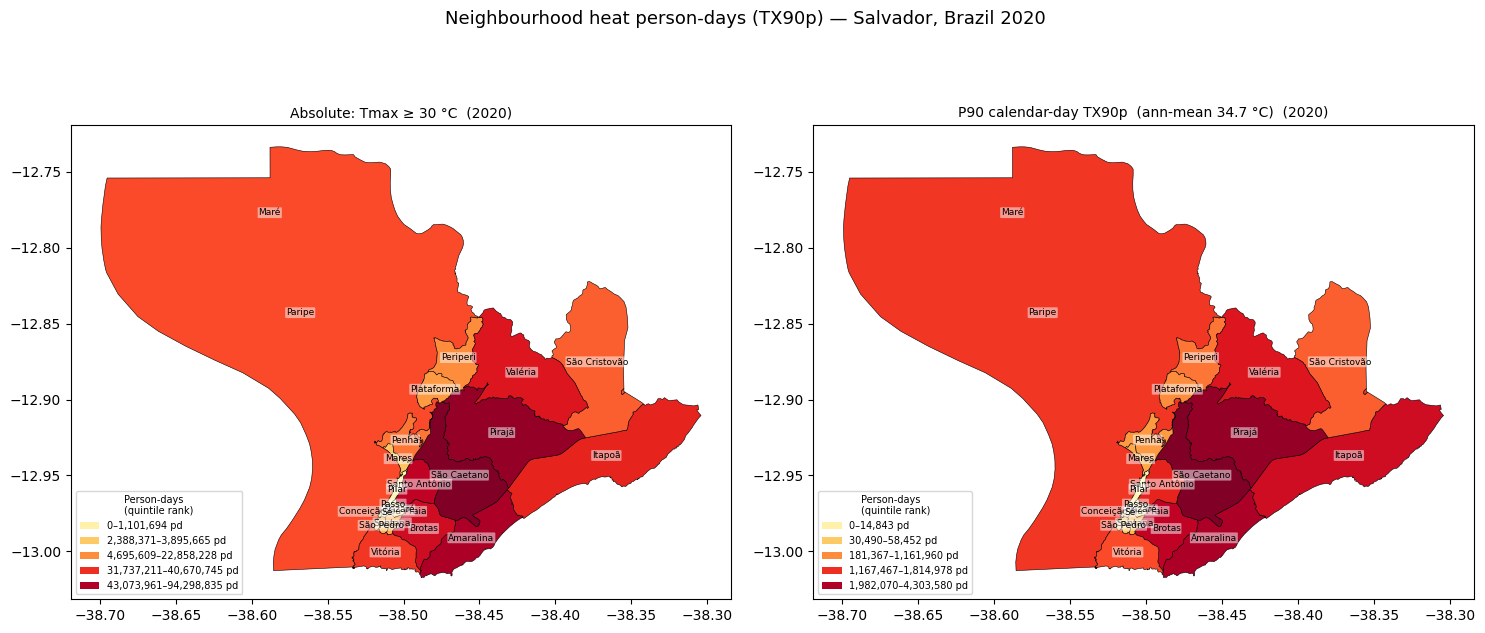

In [5]:
abs_pd_sal, tx_pd_sal = plot_tx90p_person_days_maps('salvador', YEAR, PERCENTILE)

### Teresina

/tmp/ipykernel_25945/245316473.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = mcm.get_cmap('YlOrRd')


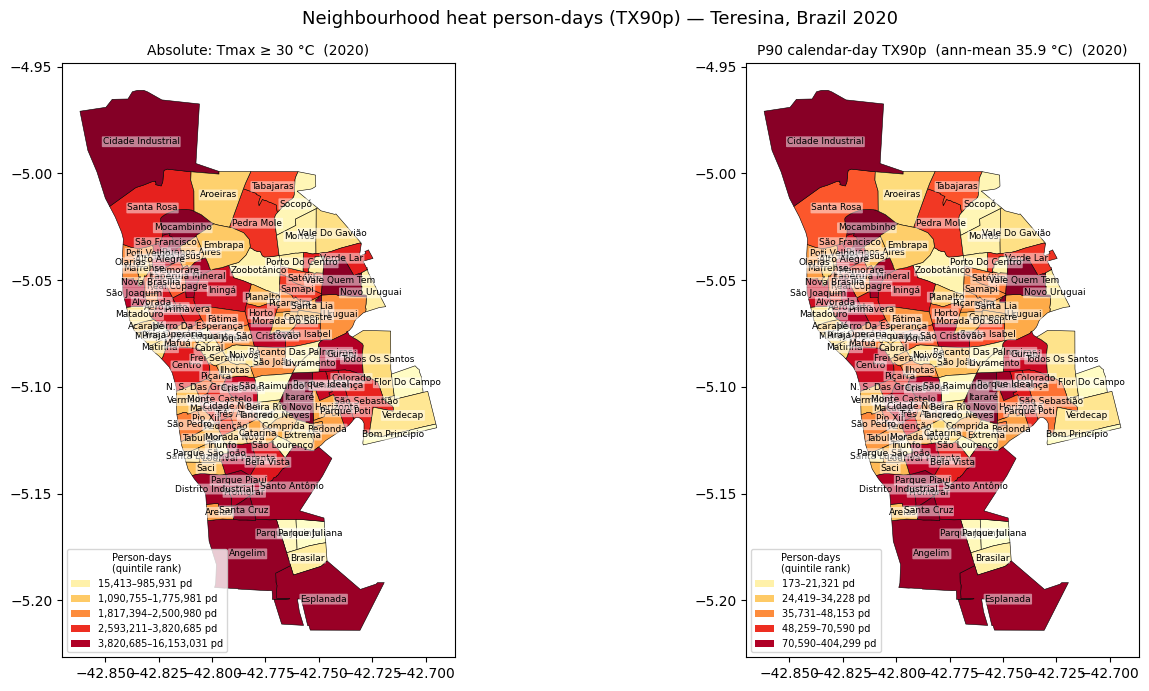

In [6]:
abs_pd_ter, tx_pd_ter = plot_tx90p_person_days_maps('teresina', YEAR, PERCENTILE)

### C\u00e1ceres

/tmp/ipykernel_25945/245316473.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = mcm.get_cmap('YlOrRd')


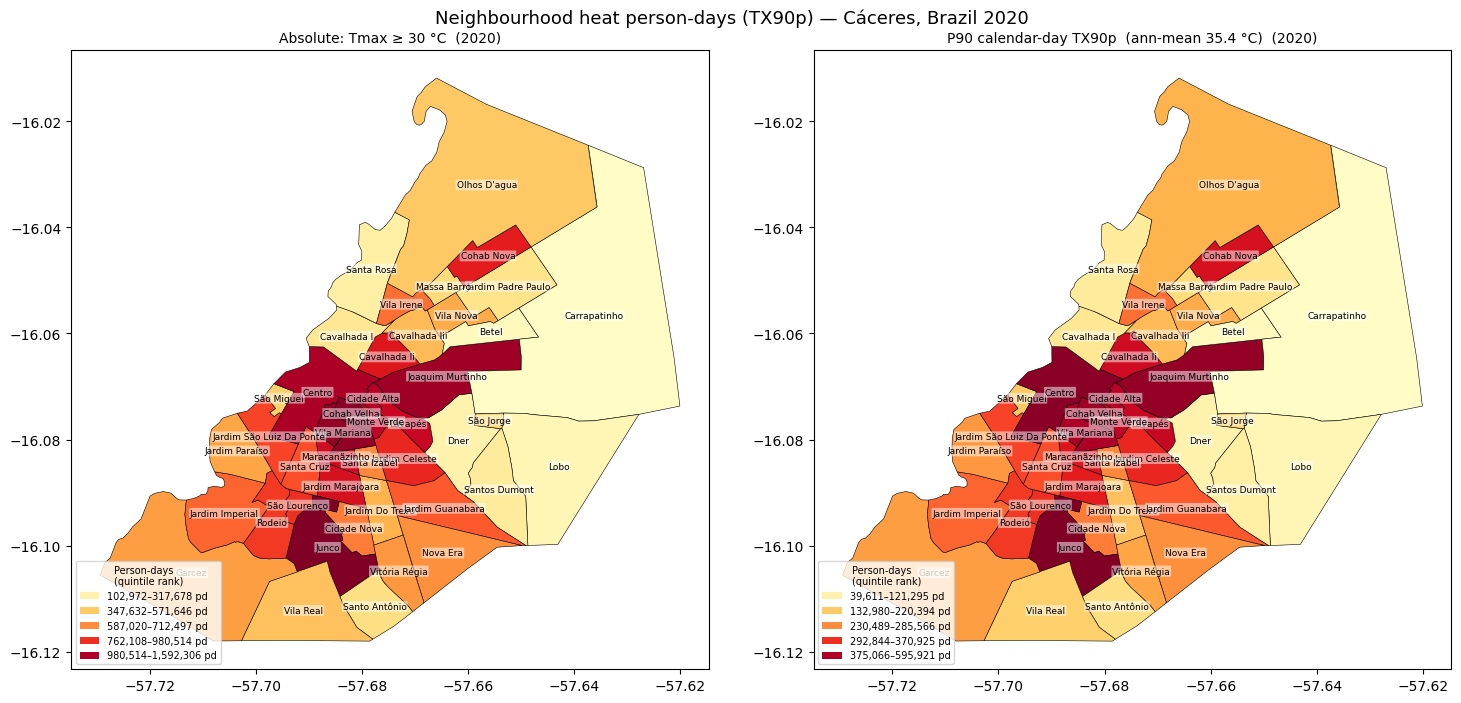

In [7]:
abs_pd_cac, tx_pd_cac = plot_tx90p_person_days_maps('caceres', YEAR, PERCENTILE)

## Neighbourhood prioritisation

Rank each neighbourhood simultaneously on absolute and TX90p person-days.
Neighbourhoods in the top-right quadrant (high rank on both framings) are
robust priorities regardless of which threshold method is applied.

Spearman rho quantifies rank agreement; values near 1 mean the choice between
absolute and calendar-day framing barely alters the prioritisation.

### Salvador

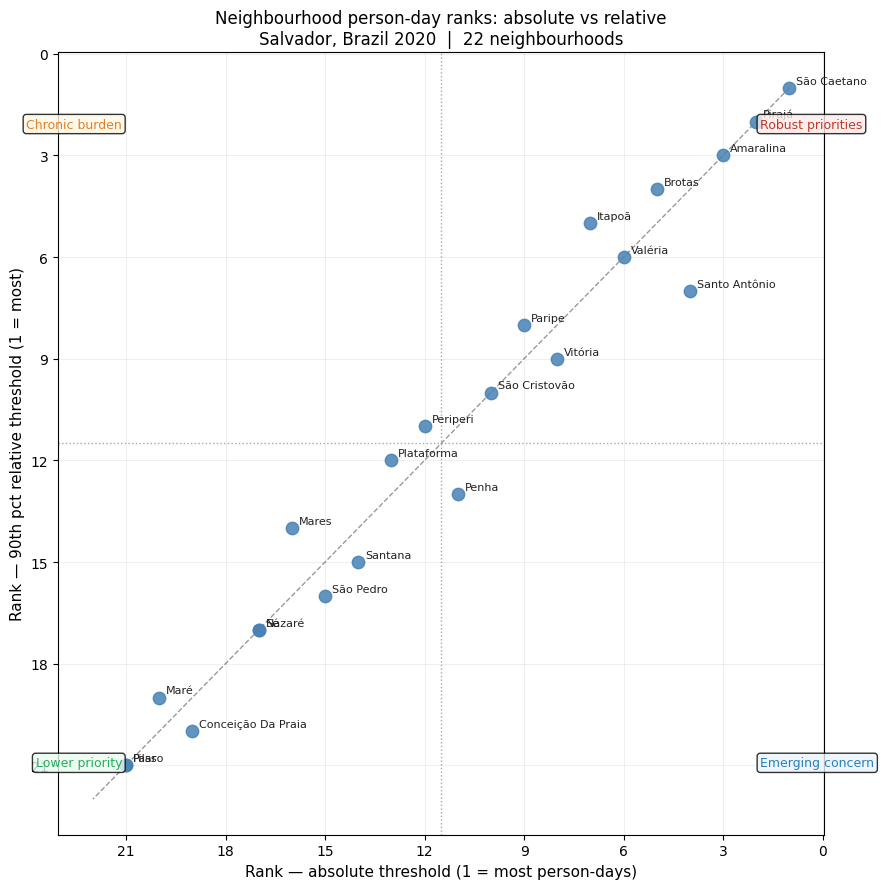

Spearman rho = 0.983  (p = <0.001,  n = 22)


In [8]:
plot_person_days_quadrant(abs_pd_sal, tx_pd_sal, YEAR, PERCENTILE, CITIES['salvador']['label'])

### Teresina

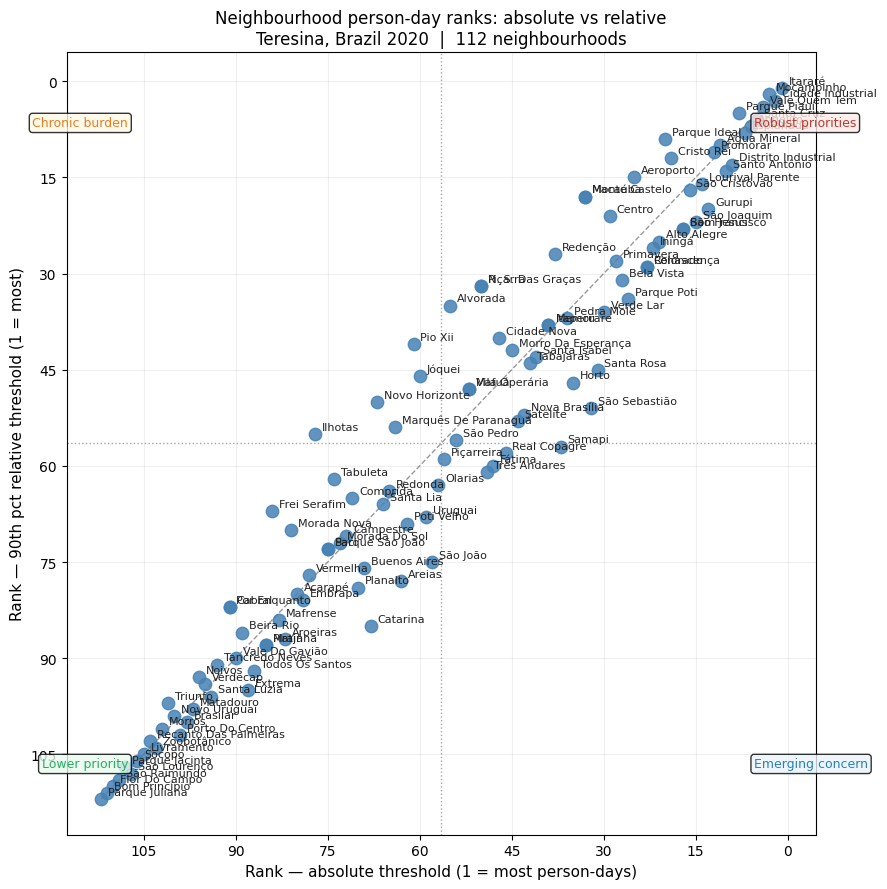

Spearman rho = 0.967  (p = <0.001,  n = 112)


In [9]:
plot_person_days_quadrant(abs_pd_ter, tx_pd_ter, YEAR, PERCENTILE, CITIES['teresina']['label'])

### C\u00e1ceres

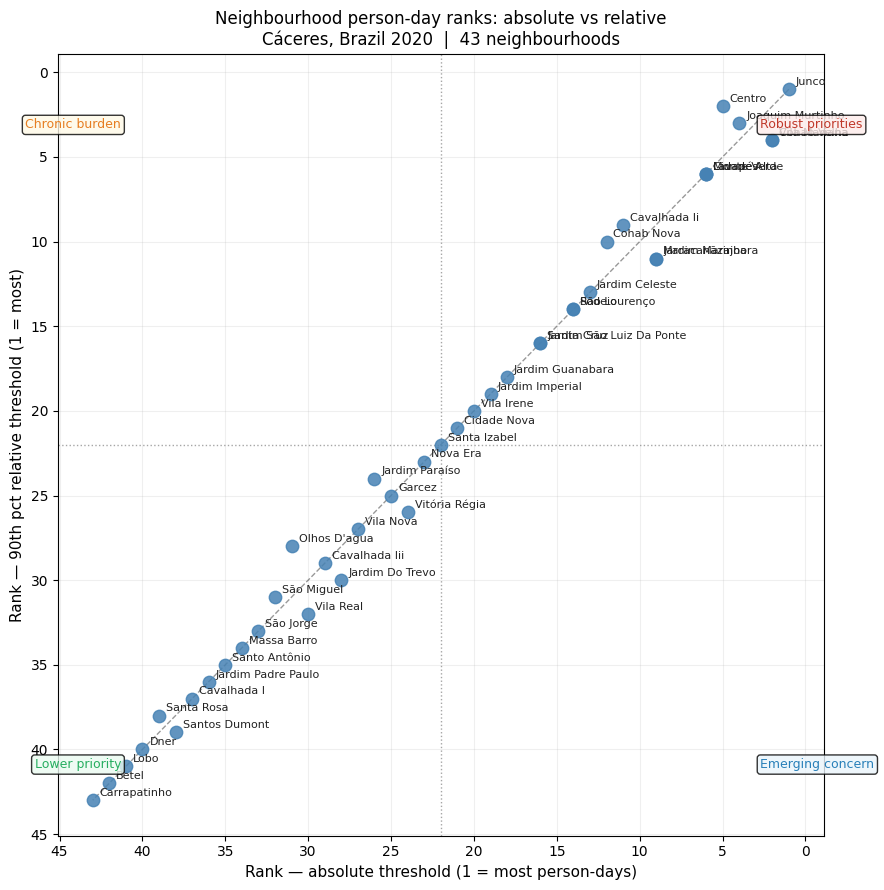

Spearman rho = 0.995  (p = <0.001,  n = 43)


In [10]:
plot_person_days_quadrant(abs_pd_cac, tx_pd_cac, YEAR, PERCENTILE, CITIES['caceres']['label'])

## Annual person-days time series \u2014 2003\u20132020

City-wide total person-days per year (sum across all pixels) for the absolute threshold
and all three calendar-day percentile levels.  Trends capture both changing heat-day
frequency *and* population growth.

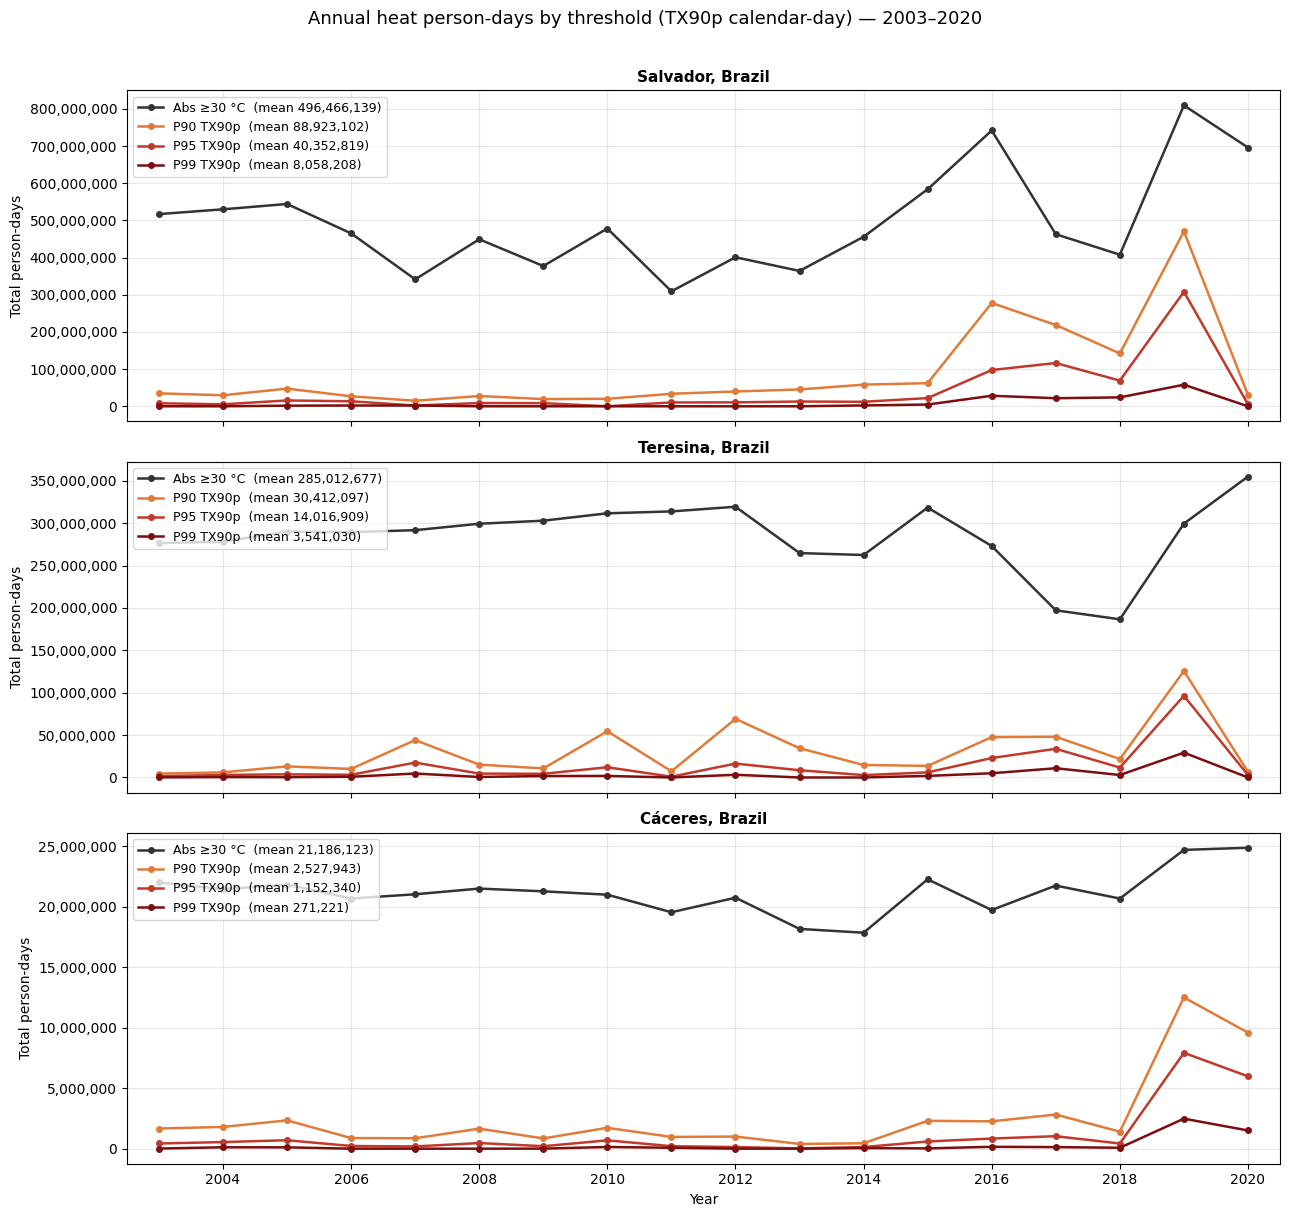

,Abs ≥30 °C,P90,P95,P99
City,,,,
"Salvador, Brazil","496,466,139","88,923,102","40,352,819","8,058,208"
"Teresina, Brazil","285,012,677","30,412,097","14,016,909","3,541,030"
"Cáceres, Brazil","21,186,123","2,527,943","1,152,340","271,221"


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True, sharey=False)

period_rows = []

for ax, c in zip(axes, CITY_KEYS):
    label      = CITIES[c]['label']
    da         = cities[c]
    period_row = {'City': label}

    # Absolute threshold
    abs_key = f'Abs \u2265{ABS_THRESHOLD:.0f} \u00b0C'
    abs_annual = []
    for yr in ALL_YEARS:
        pop_grid = load_pop_grid(c, yr)
        heat_map = compute_absolute_heat_days(da, yr, ABS_THRESHOLD)
        pd_map   = compute_person_days_map(heat_map, pop_grid)
        abs_annual.append(float(pd_map.sum()))

    mean_abs = float(np.mean(abs_annual))
    period_row[abs_key] = mean_abs
    ax.plot(ALL_YEARS, abs_annual, marker='o', markersize=4, linewidth=1.8,
            color=COLOURS[abs_key], label=f'{abs_key}  (mean {mean_abs:,.0f})')

    # Calendar-day TX90p thresholds
    for p in TX90P_PERCENTILES:
        tx_annual_pd = []
        for yr in ALL_YEARS:
            pop_grid = load_pop_grid(c, yr)
            tx_yr    = (
                tx_annual[c][p]
                .isel(time=(tx_annual[c][p].time.dt.year == yr))
                .squeeze('time')
            )
            pd_map = compute_person_days_map(tx_yr, pop_grid)
            tx_annual_pd.append(float(pd_map.sum()))

        mean_tx = float(np.mean(tx_annual_pd))
        period_row[f'P{p}'] = mean_tx
        ax.plot(ALL_YEARS, tx_annual_pd, marker='o', markersize=4, linewidth=1.8,
                color=COLOURS[f'P{p}'], label=f'P{p} TX90p  (mean {mean_tx:,.0f})')

    period_rows.append(period_row)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Total person-days')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(ALL_YEARS[0] - 0.5, ALL_YEARS[-1] + 0.5)
    ax.xaxis.set_major_locator(plt.MultipleLocator(2))

axes[-1].set_xlabel('Year')
fig.suptitle(
    'Annual heat person-days by threshold (TX90p calendar-day) \u2014 2003\u20132020',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

# Period-average summary table
period_df = pd.DataFrame(period_rows).set_index('City')
table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap;'},
    {'selector': 'td', 'props': 'text-align:center;'},
]
display(
    period_df.style
    .format('{:,.0f}')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0)
    .set_caption(
        '2003\u20132020 period averages \u2014 mean annual city-wide person-days (TX90p)'
    )
    .set_table_styles(table_styles)
)

## Threshold comparison summary

Average annual person-days per city (2003\u20132020) under one absolute threshold
and three calendar-day TX90p percentile levels.  A second table shows the annual-mean
threshold temperature for each percentile \u2014 the calendar-day equivalent of the
percentile-to-temperature mapping in notebook 04.

In [12]:
count_rows = []
temp_rows  = []

for c in CITY_KEYS:
    da    = cities[c]
    label = CITIES[c]['label']

    abs_key = f'Abs \u2265{ABS_THRESHOLD:.0f} \u00b0C'
    abs_annual = []
    for yr in ALL_YEARS:
        pop_grid = load_pop_grid(c, yr)
        heat_map = compute_absolute_heat_days(da, yr, ABS_THRESHOLD)
        abs_annual.append(float(compute_person_days_map(heat_map, pop_grid).sum()))
    count_row = {'City': label, abs_key: float(np.mean(abs_annual))}
    temp_row  = {'City': label}

    for p in TX90P_PERCENTILES:
        thr_map = thresholds[c].sel(percentile=p)
        tx_annual_pd = []
        for yr in ALL_YEARS:
            pop_grid = load_pop_grid(c, yr)
            tx_yr    = (
                tx_annual[c][p]
                .isel(time=(tx_annual[c][p].time.dt.year == yr))
                .squeeze('time')
            )
            tx_annual_pd.append(float(compute_person_days_map(tx_yr, pop_grid).sum()))
        count_row[f'P{p} TX90p'] = float(np.mean(tx_annual_pd))
        temp_row[f'P{p} (\u00b0C)'] = float(thr_map.mean())

    count_rows.append(count_row)
    temp_rows.append(temp_row)

counts = pd.DataFrame(count_rows).set_index('City')
temps  = pd.DataFrame(temp_rows).set_index('City')

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap;'},
    {'selector': 'td', 'props': 'text-align:center;'},
]

display(
    counts.style
    .format('{:,.0f}')
    .background_gradient(cmap='YlOrRd', axis=None, vmin=0)
    .set_caption(
        'Average annual person-days per city \u2014 2003\u20132020  '
        '(TX90p calendar-day thresholds, city-wide total)'
    )
    .set_table_styles(table_styles)
)

print()

display(
    temps.style
    .format('{:.1f}')
    .set_caption(
        'Annual-mean calendar-day threshold temperature by city  '
        '(spatial mean \u00b0C, averaged across all 365 days)'
    )
    .set_table_styles(table_styles)
)

,Abs ≥30 °C,P90 TX90p,P95 TX90p,P99 TX90p
City,,,,
"Salvador, Brazil","496,466,139","88,923,102","40,352,819","8,058,208"
"Teresina, Brazil","285,012,677","30,412,097","14,016,909","3,541,030"
"Cáceres, Brazil","21,186,123","2,527,943","1,152,340","271,221"


,P90 (°C),P95 (°C),P99 (°C)
City,,,
"Salvador, Brazil",34.7,37.2,44.2
"Teresina, Brazil",35.9,37.0,40.9
"Cáceres, Brazil",35.4,36.5,39.8


## Population-dominance diagnostic

Coefficient of variation (CV) of person-days vs raw population across neighbourhoods.
If population CV >> person-days CV, population is dominating the ranking signal
and heat-day differences between neighbourhoods barely alter the ordering.

## Neighbourhood-level diagnostic table

Per-neighbourhood breakdown of population, heat days (absolute and TX90p), and person-days
for a single representative year.  Intended to reveal whether population variation or
heat-day variation is driving person-day rankings — and whether the two heat-day methods
agree spatially.

In [14]:
from scipy.stats import spearmanr, pearsonr

DIAG_YEAR = YEAR  # change if you want a different year

def build_diagnostic_table(city_key: str, year: int) -> pd.DataFrame:
    """
    Per-neighbourhood table of population, heat-day counts (abs + TX90p),
    person-days, and ranks for each.  Also prints summary stats and correlations.
    """
    da    = cities[city_key]
    gdf   = gdfs[city_key]
    label = CITIES[city_key]['label']

    pop_grid = load_pop_grid(city_key, year)

    # --- heat-day maps ---
    abs_hd = compute_absolute_heat_days(da, year, ABS_THRESHOLD)
    tx_hd  = (
        tx_annual[city_key][PERCENTILE]
        .isel(time=(tx_annual[city_key][PERCENTILE].time.dt.year == year))
        .squeeze('time')
    )

    # --- person-days maps ---
    abs_pd_map = compute_person_days_map(abs_hd, pop_grid)
    tx_pd_map  = compute_person_days_map(tx_hd,  pop_grid)

    # --- aggregate to neighbourhoods ---
    pop_nbhd    = aggregate_person_days_to_neighbourhoods(pop_grid,   gdf, col='population')
    abs_hd_nbhd = aggregate_to_neighbourhoods(abs_hd, gdf, col='abs_heat_days')
    tx_hd_nbhd  = aggregate_to_neighbourhoods(tx_hd,  gdf, col='tx90p_heat_days')
    abs_pd_nbhd = aggregate_person_days_to_neighbourhoods(abs_pd_map, gdf, col='abs_person_days')
    tx_pd_nbhd  = aggregate_person_days_to_neighbourhoods(tx_pd_map,  gdf, col='tx90p_person_days')

    df = gdf[['name']].copy()
    df['population']        = pop_nbhd['population'].values
    df['abs_heat_days']     = abs_hd_nbhd['abs_heat_days'].values
    df['tx90p_heat_days']   = tx_hd_nbhd['tx90p_heat_days'].values
    df['heatday_diff']      = df['abs_heat_days'] - df['tx90p_heat_days']
    df['abs_person_days']   = abs_pd_nbhd['abs_person_days'].values
    df['tx90p_person_days'] = tx_pd_nbhd['tx90p_person_days'].values
    df['rank_abs_pd']       = df['abs_person_days'].rank(ascending=False, method='min').astype(int)
    df['rank_tx90p_pd']     = df['tx90p_person_days'].rank(ascending=False, method='min').astype(int)
    df['rank_abs_hd']       = df['abs_heat_days'].rank(ascending=False, method='min').astype(int)
    df['rank_tx90p_hd']     = df['tx90p_heat_days'].rank(ascending=False, method='min').astype(int)
    df['rank_pop']          = df['population'].rank(ascending=False, method='min').astype(int)

    df = df.sort_values('abs_person_days', ascending=False).reset_index(drop=True)

    # --- summary statistics ---
    print(f'\n{"="*60}')
    print(f'  {label}  —  {year}')
    print(f'{"="*60}')

    stats_cols = ['population', 'abs_heat_days', 'tx90p_heat_days', 'abs_person_days', 'tx90p_person_days']
    stats = df[stats_cols].agg(['mean', 'std', 'min', 'max']).T
    stats.insert(0, 'CV', df[stats_cols].std() / df[stats_cols].mean())
    print('\nDescriptive stats (neighbourhood level):')
    print(stats.to_string(float_format='{:,.2f}'.format))

    # --- correlations ---
    valid = df.dropna(subset=stats_cols)
    print('\nSpearman rank correlations (neighbourhood level):')
    pairs = [
        ('population',      'abs_person_days',   'pop vs abs_pd'),
        ('population',      'tx90p_person_days',  'pop vs tx90p_pd'),
        ('population',      'abs_heat_days',      'pop vs abs_heatdays'),
        ('population',      'tx90p_heat_days',    'pop vs tx90p_heatdays'),
        ('abs_heat_days',   'tx90p_heat_days',    'abs_hd vs tx90p_hd'),
        ('abs_heat_days',   'abs_person_days',    'abs_hd vs abs_pd'),
        ('tx90p_heat_days', 'tx90p_person_days',  'tx90p_hd vs tx90p_pd'),
        ('abs_person_days', 'tx90p_person_days',  'abs_pd vs tx90p_pd  ← key'),
    ]
    for a, b, lbl in pairs:
        rho, p = spearmanr(valid[a], valid[b])
        print(f'  {lbl:<38}  rho={rho:+.3f}  p={p:.3f}')

    return df


# Need aggregate_to_neighbourhoods for heat-day (mean) aggregation
from utils.heat import aggregate_to_neighbourhoods

diag_tables = {}
for c in CITY_KEYS:
    diag_tables[c] = build_diagnostic_table(c, DIAG_YEAR)


  Salvador, Brazil  —  2020

Descriptive stats (neighbourhood level):
                    CV          mean           std    min           max
population        1.04    114,310.35    119,048.09 925.35    395,082.42
abs_heat_days     0.44        189.38         83.58   0.00        244.00
tx90p_heat_days   0.64          6.72          4.31   0.00         12.00
abs_person_days   1.10 25,421,143.08 27,940,061.75   0.00 94,298,834.64
tx90p_person_days 1.19  1,091,936.71  1,298,863.31   0.00  4,303,579.56

Spearman rank correlations (neighbourhood level):
  pop vs abs_pd                           rho=+0.985  p=0.000
  pop vs tx90p_pd                         rho=+0.966  p=0.000
  pop vs abs_heatdays                     rho=+0.250  p=0.263
  pop vs tx90p_heatdays                   rho=+0.531  p=0.011
  abs_hd vs tx90p_hd                      rho=+0.498  p=0.018
  abs_hd vs abs_pd                        rho=+0.331  p=0.133
  tx90p_hd vs tx90p_pd                    rho=+0.701  p=0.000
  abs_pd vs 

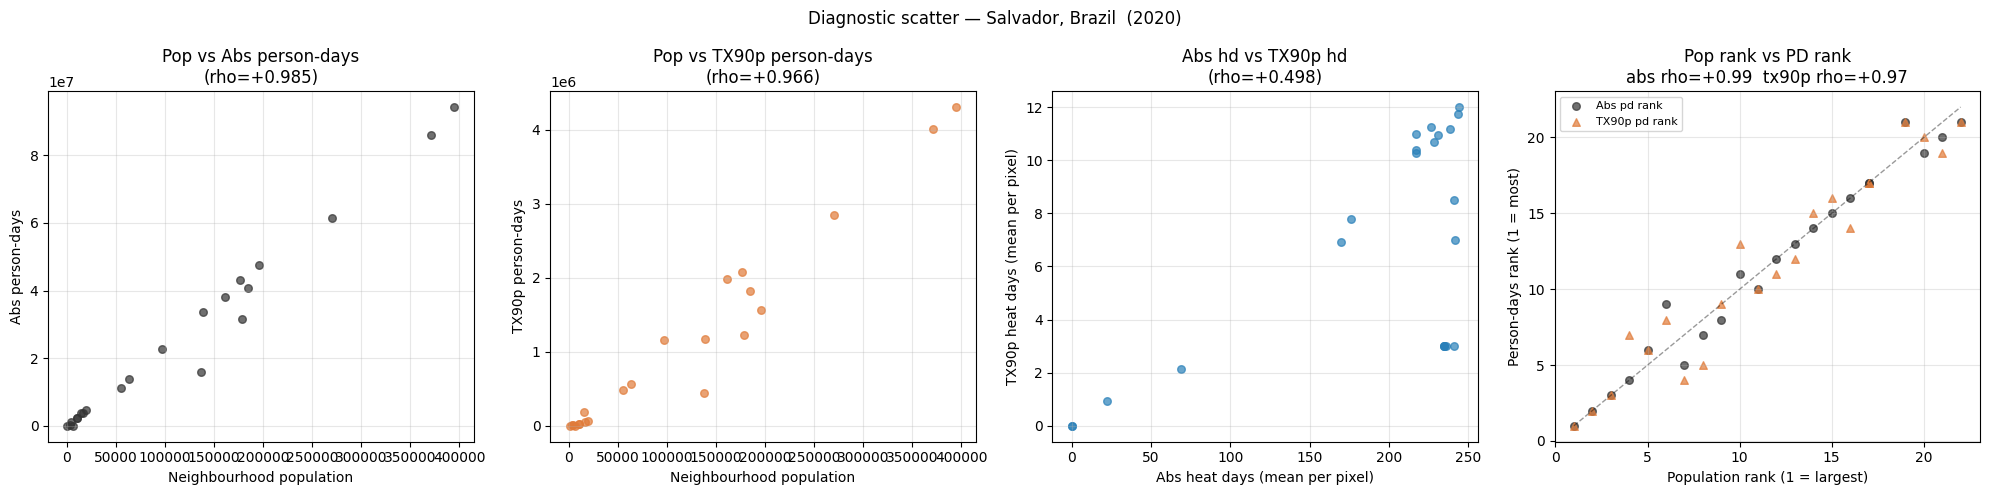

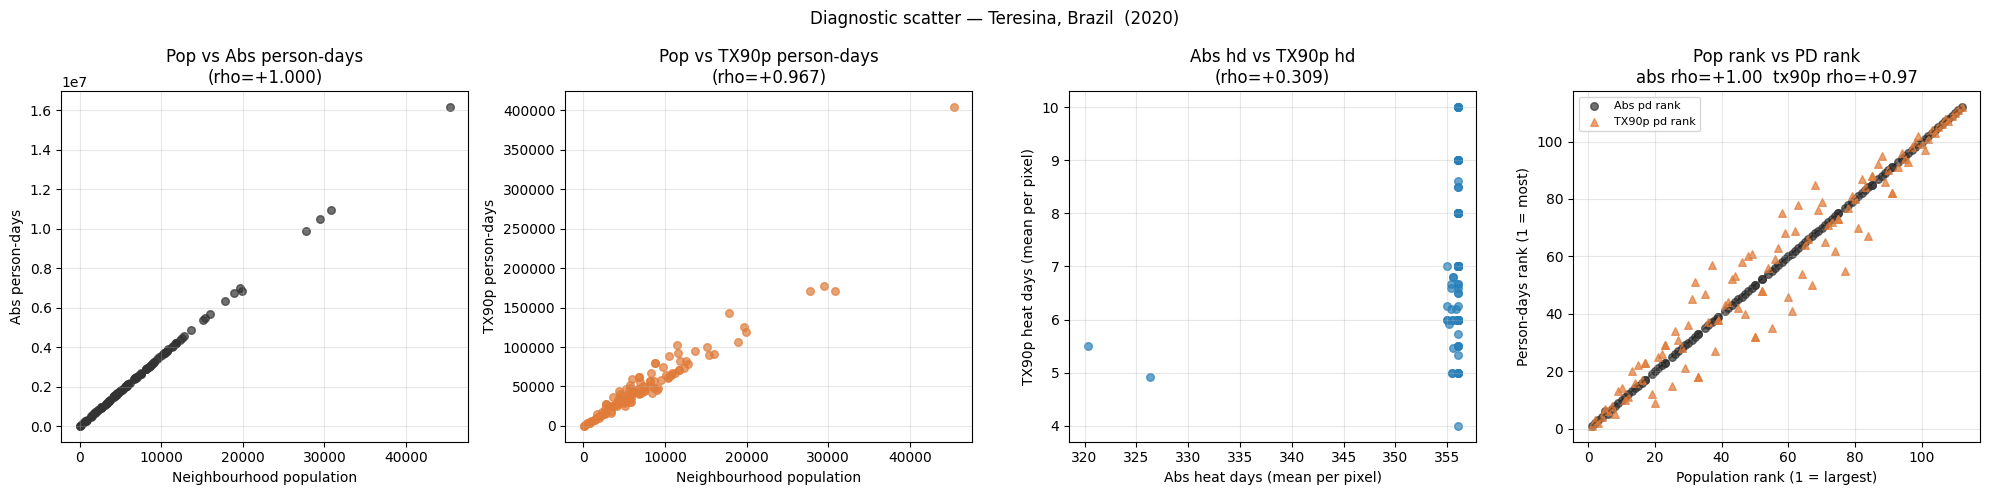

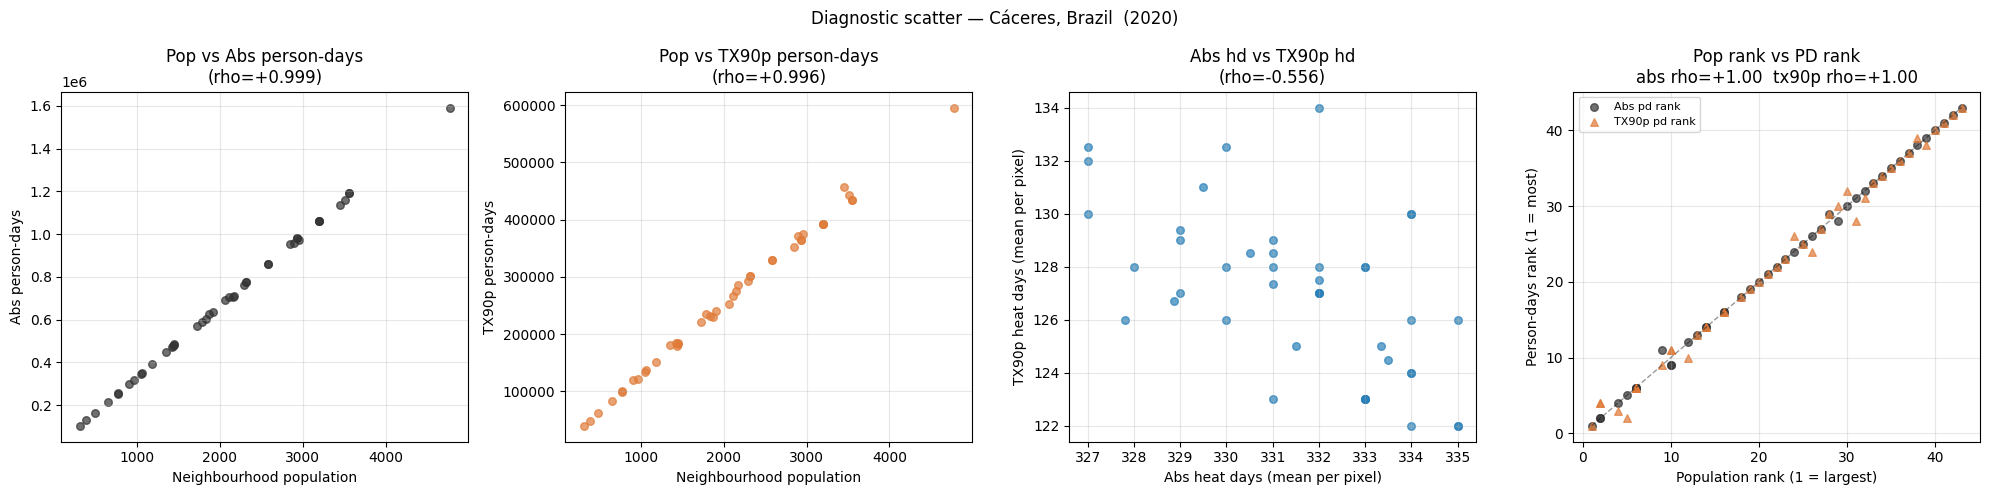

In [15]:
def plot_diagnostic_scatter(df: pd.DataFrame, city_label: str) -> None:
    """
    4-panel scatter for one city:
      1. population vs abs_person_days
      2. population vs tx90p_person_days
      3. abs_heat_days vs tx90p_heat_days  (do the two methods see the same spatial pattern?)
      4. rank_pop vs rank_abs_pd / rank_tx90p_pd overlaid  (does pop rank ≈ person-day rank?)
    """
    valid = df.dropna(subset=['population', 'abs_person_days', 'tx90p_person_days',
                               'abs_heat_days', 'tx90p_heat_days'])

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Diagnostic scatter — {city_label}  ({DIAG_YEAR})', fontsize=12)

    # Panel 1: pop vs abs person-days
    ax = axes[0]
    ax.scatter(valid['population'], valid['abs_person_days'], s=30, alpha=0.7, color='#333333')
    rho, _ = spearmanr(valid['population'], valid['abs_person_days'])
    ax.set_xlabel('Neighbourhood population')
    ax.set_ylabel('Abs person-days')
    ax.set_title(f'Pop vs Abs person-days\n(rho={rho:+.3f})')
    ax.grid(True, alpha=0.3)

    # Panel 2: pop vs TX90p person-days
    ax = axes[1]
    ax.scatter(valid['population'], valid['tx90p_person_days'], s=30, alpha=0.7, color='#e07b39')
    rho, _ = spearmanr(valid['population'], valid['tx90p_person_days'])
    ax.set_xlabel('Neighbourhood population')
    ax.set_ylabel('TX90p person-days')
    ax.set_title(f'Pop vs TX90p person-days\n(rho={rho:+.3f})')
    ax.grid(True, alpha=0.3)

    # Panel 3: abs heat days vs TX90p heat days (spatial agreement of the two methods)
    ax = axes[2]
    ax.scatter(valid['abs_heat_days'], valid['tx90p_heat_days'], s=30, alpha=0.7, color='#2980b9')
    rho, _ = spearmanr(valid['abs_heat_days'], valid['tx90p_heat_days'])
    ax.set_xlabel('Abs heat days (mean per pixel)')
    ax.set_ylabel('TX90p heat days (mean per pixel)')
    ax.set_title(f'Abs hd vs TX90p hd\n(rho={rho:+.3f})')
    ax.grid(True, alpha=0.3)

    # Panel 4: population rank vs person-day rank (both methods)
    ax = axes[3]
    n = len(valid)
    ax.scatter(valid['rank_pop'], valid['rank_abs_pd'],   s=30, alpha=0.7,
               color='#333333', label='Abs pd rank')
    ax.scatter(valid['rank_pop'], valid['rank_tx90p_pd'], s=30, alpha=0.7,
               color='#e07b39', label='TX90p pd rank', marker='^')
    ax.plot([1, n], [1, n], 'k--', linewidth=1, alpha=0.4)
    rho_abs,  _ = spearmanr(valid['rank_pop'], valid['rank_abs_pd'])
    rho_tx,   _ = spearmanr(valid['rank_pop'], valid['rank_tx90p_pd'])
    ax.set_xlabel('Population rank (1 = largest)')
    ax.set_ylabel('Person-days rank (1 = most)')
    ax.set_title(f'Pop rank vs PD rank\nabs rho={rho_abs:+.2f}  tx90p rho={rho_tx:+.2f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


for c in CITY_KEYS:
    plot_diagnostic_scatter(diag_tables[c], CITIES[c]['label'])

In [16]:
table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td', 'props': 'text-align:right; font-size:0.83em;'},
]

for c in CITY_KEYS:
    df = diag_tables[c].copy()
    label = CITIES[c]['label']

    fmt = {
        'population':        '{:,.0f}',
        'abs_heat_days':     '{:.1f}',
        'tx90p_heat_days':   '{:.1f}',
        'heatday_diff':      '{:+.1f}',
        'abs_person_days':   '{:,.0f}',
        'tx90p_person_days': '{:,.0f}',
        'rank_abs_pd':       '{:d}',
        'rank_tx90p_pd':     '{:d}',
        'rank_abs_hd':       '{:d}',
        'rank_tx90p_hd':     '{:d}',
        'rank_pop':          '{:d}',
    }

    # Highlight rank disagreements between abs_pd and tx90p_pd
    def highlight_rank_diff(row):
        diff = abs(row['rank_abs_pd'] - row['rank_tx90p_pd'])
        if diff == 0:
            bg = ''
        elif diff <= 3:
            bg = 'background-color: #fff3cd'
        else:
            bg = 'background-color: #f8d7da'
        return [''] * (len(row) - 2) + [bg, bg]

    styled = (
        df.style
        .format(fmt)
        .background_gradient(subset=['population'], cmap='Blues', axis=0)
        .background_gradient(subset=['abs_heat_days', 'tx90p_heat_days'], cmap='YlOrRd', axis=0)
        .background_gradient(subset=['abs_person_days', 'tx90p_person_days'], cmap='Oranges', axis=0)
        .apply(highlight_rank_diff, axis=1)
        .set_caption(
            f'{label}  —  neighbourhood diagnostic table  ({DIAG_YEAR})  '
            '| rank columns: 1 = highest  '
            '| yellow/red rows = abs vs TX90p pd rank differs by >0 / >3'
        )
        .set_table_styles(table_styles)
    )
    display(styled)
    print()

,name,population,abs_heat_days,tx90p_heat_days,heatday_diff,abs_person_days,tx90p_person_days,rank_abs_pd,rank_tx90p_pd,rank_abs_hd,rank_tx90p_hd,rank_pop
0,São Caetano,"395,082",238.7,11.2,+227.5,"94,298,835","4,303,580",1,1,6,4,1
1,Pirajá,"371,435",231.0,10.9,+220.1,"86,080,236","4,006,178",2,2,11,6,2
2,Amaralina,"270,322",228.8,10.7,+218.1,"61,558,767","2,845,064",3,3,12,7,3
3,Santo Antônio,"195,988",241.9,7.0,+234.9,"47,481,205","1,562,627",4,7,3,12,4
4,Brotas,"177,034",243.6,11.7,+231.9,"43,073,961","2,078,214",5,4,2,2,7
5,Valéria,"184,514",217.4,10.3,+207.1,"40,670,745","1,814,978",6,6,14,9,5
6,Itapoã,"161,716",226.5,11.3,+215.2,"38,131,424","1,982,070",7,5,13,3,8
7,Vitória,"139,139",241.0,8.5,+232.5,"33,607,400","1,167,467",8,9,4,10,9
8,Paripe,"178,883",22.1,0.9,+21.2,"31,737,211","1,226,715",9,8,20,20,6
9,São Cristovão,"97,518",217.2,11.0,+206.3,"22,858,228","1,161,960",10,10,16,5,11


,name,population,abs_heat_days,tx90p_heat_days,heatday_diff,abs_person_days,tx90p_person_days,rank_abs_pd,rank_tx90p_pd,rank_abs_hd,rank_tx90p_hd,rank_pop
0,Itararé,"45,374",356.0,8.6,+347.4,"16,153,031","404,299",1,1,1,15,1
1,Cidade Industrial,"30,806",355.2,5.9,+349.3,"10,957,505","171,707",2,3,106,96,2
2,Mocambinho,"29,507",356.0,6.0,+350.0,"10,504,486","177,042",3,2,1,68,3
3,Vale Quem Tem,"27,801",355.0,6.2,+348.8,"9,869,277","170,975",4,4,107,64,4
4,Santa Cruz,"19,620",356.0,6.0,+350.0,"6,984,832","125,403",5,6,1,68,6
5,Angelim,"19,959",320.3,5.5,+314.8,"6,840,545","119,031",6,7,112,98,5
6,Esplanada,"18,888",355.5,5.5,+350.1,"6,723,222","106,497",7,8,99,102,7
7,Parque Piauí,"17,843",356.0,8.0,+348.0,"6,352,028","142,742",8,5,1,18,8
8,Distrito Industrial,"15,944",356.0,5.3,+350.7,"5,676,005","91,695",9,13,1,103,9
9,Santo Antônio,"15,354",356.0,5.7,+350.3,"5,466,036","89,493",10,14,1,97,10


,name,population,abs_heat_days,tx90p_heat_days,heatday_diff,abs_person_days,tx90p_person_days,rank_abs_pd,rank_tx90p_pd,rank_abs_hd,rank_tx90p_hd,rank_pop
0,Junco,"4,775",333.3,125.0,+208.3,"1,592,306","595,921",1,1,11,31,1
1,Vila Mariana,"3,553",335.0,122.0,+213.0,"1,190,408","433,522",2,4,1,41,2
2,Cohab Velha,"3,553",335.0,122.0,+213.0,"1,190,408","433,522",2,4,1,41,2
3,Joaquim Murtinho,"3,508",331.0,127.3,+203.7,"1,161,006","443,105",4,3,25,21,4
4,Centro,"3,454",330.0,132.5,+197.5,"1,138,379","456,557",5,2,31,2,5
5,Lavapés,"3,194",333.0,123.0,+210.0,"1,063,499","392,824",6,6,12,36,6
6,Monte Verde,"3,194",333.0,123.0,+210.0,"1,063,499","392,824",6,6,12,36,6
7,Cidade Alta,"3,194",333.0,123.0,+210.0,"1,063,499","392,824",6,6,12,36,6
8,Jardim Marajoara,"2,936",334.0,124.0,+210.0,"980,514","364,023",9,11,4,34,10
9,Maracanãzinho,"2,936",334.0,124.0,+210.0,"980,514","364,023",9,11,4,34,10


In [17]:
print('--- CV diagnostic: does population dominate TX90p person-days ranking? ---')
for c, abs_gdf, tx_gdf in zip(
    CITY_KEYS,
    [abs_pd_sal, abs_pd_ter, abs_pd_cac],
    [tx_pd_sal,  tx_pd_ter,  tx_pd_cac],
):
    label  = CITIES[c]['label']
    abs_cv = abs_gdf['total_person_days'].std() / abs_gdf['total_person_days'].mean()
    tx_cv  = tx_gdf['total_person_days'].std()  / tx_gdf['total_person_days'].mean()

    pop_g    = load_pop_grid(c, YEAR)
    pop_nbhd = aggregate_person_days_to_neighbourhoods(pop_g, gdfs[c], col='total_person_days')
    pop_cv   = pop_nbhd['total_person_days'].std() / pop_nbhd['total_person_days'].mean()

    print(f'\n{label}')
    print(f'  person-days CV:  abs={abs_cv:.3f}  tx90p={tx_cv:.3f}')
    print(f'  population CV:   {pop_cv:.3f}')

--- CV diagnostic: does population dominate TX90p person-days ranking? ---

Salvador, Brazil
  person-days CV:  abs=1.099  tx90p=1.190
  population CV:   1.041

Teresina, Brazil
  person-days CV:  abs=0.877  tx90p=0.934
  population CV:   0.878

Cáceres, Brazil
  person-days CV:  abs=0.508  tx90p=0.497
  population CV:   0.506


## Summary

Key outputs from this notebook:

1. **Spatial maps** \u2014 person-days exposure at neighbourhood level using calendar-day TX90p
   thresholds; shows how population distribution amplifies or dampens the seasonal-adjusted
   heat-day signal.

2. **Quadrant plots** \u2014 identify neighbourhoods robustly high-burden under *both*
   the absolute threshold and the TX90p calendar-day framing, accounting for population size.

3. **Time series** \u2014 city-wide annual totals from 2003\u20132020 combining heat-day trends
   (seasonally calibrated) with population growth.

4. **Summary tables** \u2014 average annual person-days per city/threshold plus the
   annual-mean threshold temperature at each percentile level.

5. **CV diagnostic** \u2014 confirms whether heat-day spatial variation or population
   spatial variation drives neighbourhood rankings under the TX90p framing.

**Comparison with notebook 04:** swap `baselines` (flat annual percentile) for `thresholds`
(calendar-day 5-day-window percentile) to see how removing the annual cycle changes
both the absolute level and the spatial pattern of person-days exposure.

To change the analysis year, absolute threshold, or TX90p percentile level, edit the
parameters in the Setup cell and re-run.